In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV files
df1 = pd.read_csv('wandb1.csv')
df2 = pd.read_csv('wandb2.csv')
df3 = pd.read_csv('wandb3.csv')

# Display basic information about the dataframes
print("DataFrame 1 shape:", df1.shape)
print("DataFrame 2 shape:", df2.shape)
print("DataFrame 3 shape:", df3.shape)

# Display the first few rows of each dataframe
print("\nDataFrame 1 head:")
display(df1.head())

print("\nDataFrame 2 head:")
display(df2.head())

print("\nDataFrame 3 head:")
display(df3.head())


DataFrame 1 shape: (12, 4)
DataFrame 2 shape: (10000, 4)
DataFrame 3 shape: (1711, 4)

DataFrame 1 head:


,Step,quiet-wood-126 - train_tm_score,quiet-wood-126 - train_tm_score__MIN,quiet-wood-126 - train_tm_score__MAX
0,2150,0.276112,0.276112,0.276112
1,4301,0.311360,0.311360,0.311360
2,6452,0.323770,0.323770,0.323770
3,8603,0.330097,0.330097,0.330097
4,10754,0.334584,0.334584,0.334584



DataFrame 2 head:


,Step,quiet-wood-126 - tm_score,quiet-wood-126 - tm_score__MIN,quiet-wood-126 - tm_score__MAX
0,1,0.741014,0.741014,0.741014
1,2,0.011611,0.011611,0.011611
2,3,0.916494,0.916494,0.916494
3,6,0.002738,0.002738,0.002738
4,8,0.008981,0.008981,0.008981



DataFrame 3 head:


,Step,train-tm-score-eval-run - tm_score,train-tm-score-eval-run - tm_score__MIN,train-tm-score-eval-run - tm_score__MAX
0,0,0.733463,0.733463,0.733463
1,1,0.010575,0.010575,0.010575
2,2,0.914506,0.914506,0.914506
3,3,0.002219,0.002219,0.002219
4,4,0.002733,0.002733,0.002733


In [27]:
scores = []
eval_prompt = "Average score: "
with open('rhofold/wandb/run-20250513_060003-clzxzgws/files/output.log', 'r') as f:
    for line in f.readlines():
        if eval_prompt in line:
            scores.append(float(line[len(eval_prompt):]))
scores

[0.217014283172844,
 0.21708174515756218,
 0.21722502794684673,
 0.21777931233093104,
 0.21693686551825944,
 0.2176166701994509,
 0.21681804804838906,
 0.21766427998702964,
 0.21740766027485062,
 0.21711663928758881,
 0.21687586979040496,
 0.21688105462441457,
 0.21755350590984335,
 0.21717887700990188,
 0.21793588248950257,
 0.21664381396862886,
 0.21780239765650233,
 0.21634029417999032,
 0.2174614011779312,
 0.2172209076795159,
 0.217145855728662,
 0.21694323320413436,
 0.21690374566603077,
 0.21681623434219557,
 0.2166410736951409,
 0.21718260299327763,
 0.21629432067082527,
 0.2167421681012294,
 0.21627184648538436,
 0.21673120700727755,
 0.21644994454790456,
 0.21627776074471092,
 0.21621083104333214,
 0.2161960651092135,
 0.21618764714677205,
 0.21603943580804869,
 0.21647920041737323,
 0.21544162247532098,
 0.21590358527131784,
 0.21507401182978036,
 0.21549031654377623,
 0.21523779738473028,
 0.2150224592026506,
 0.2150032378598393,
 0.2149523555154332,
 0.21481232556877827,
 

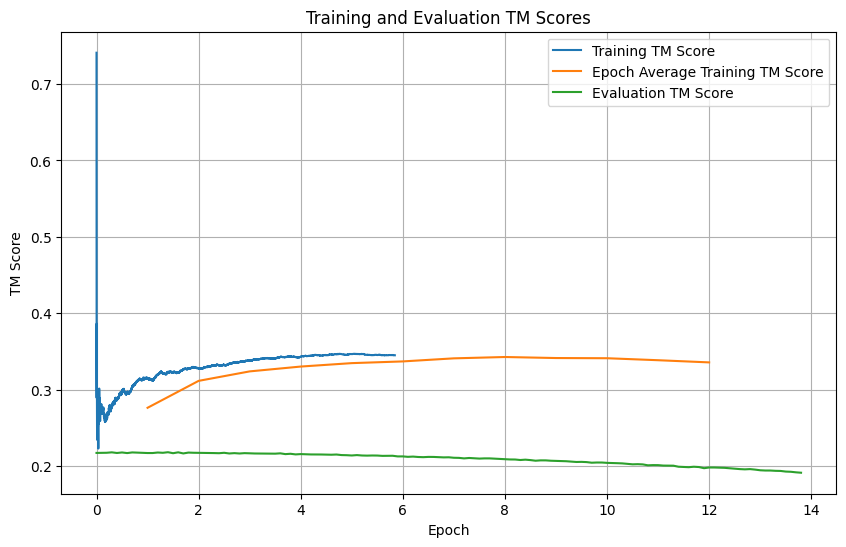

In [33]:
import seaborn as sns
import numpy as np

# Create a line plot of the train_tm_score
plt.figure(figsize=(10, 6))
# Create a new column for epoch (assuming steps are sequential)
train_score = df2['quiet-wood-126 - tm_score'].expanding().mean()
x_values = np.arange(0, len(train_score)) / len(df3)
train_scores_df = pd.DataFrame({
    'Epoch': x_values,
    'Score': train_score
})
sns.lineplot(x='Epoch', y='Score', data=train_scores_df, label='Training TM Score')

df1['Epoch'] = df1.index + 1
sns.lineplot(x='Epoch', y='quiet-wood-126 - train_tm_score', data=df1, label='Epoch Average Training TM Score')

# Create a dataframe for the scores from the log file
# Create x-axis values as multiples of 1/10 starting from 0
x_values = np.arange(0, len(scores) * 0.1, 0.1)
scores_df = pd.DataFrame({
    'Epoch': x_values,
    'Score': scores
})

# Plot the scores on the same graph
sns.lineplot(x='Epoch', y='Score', data=scores_df, label='Evaluation TM Score')

plt.title('Training and Evaluation TM Scores')
plt.xlabel('Epoch')
plt.ylabel('TM Score')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
train = df2['quiet-wood-126 - tm_score']
val = df3['train-tm-score-eval-run - tm_score']

In [12]:
len(val)

1711

/tmp/ipykernel_2390839/2803174832.py:14: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  val_repeated = pd.concat([val_repeated, val.reset_index(drop=True)])


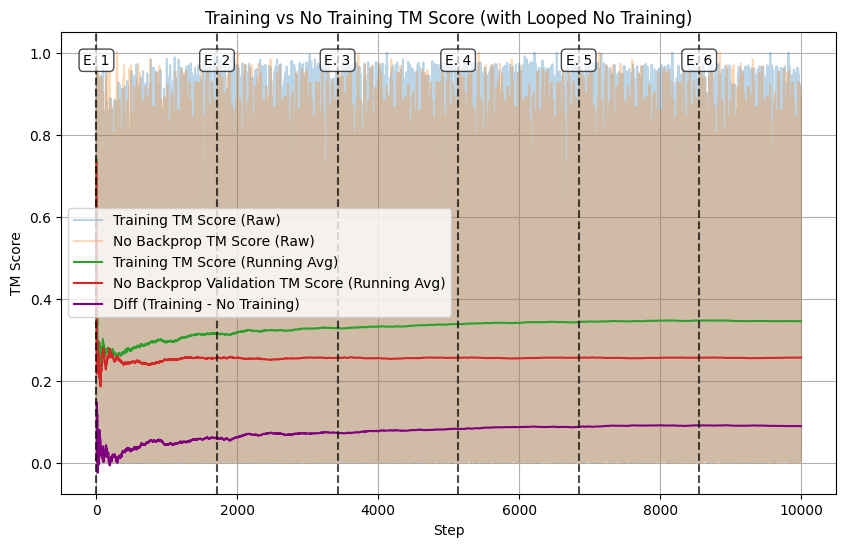

In [22]:
# Create a line plot comparing training and validation TM scores with running average
plt.figure(figsize=(10, 6))

# Extend training data by repeating validation data to match its length
extended_train = train.copy()
val_repeated = pd.Series()

# Calculate how many complete epochs we'll have
val_length = len(val)
num_epochs = (len(extended_train) + val_length - 1) // val_length  # Ceiling division

# Repeat validation data as needed to match training data length
while len(extended_train) > len(val_repeated):
    val_repeated = pd.concat([val_repeated, val.reset_index(drop=True)])

# Trim the repeated validation data to match training length exactly
val_repeated = val_repeated[:len(extended_train)]

# Create a dataframe with both train and val data
comparison_df = pd.DataFrame({
    'Training': extended_train.values,
    'Validation': val_repeated.values,
    'Index': range(1, len(extended_train) + 1)  # Index starting from 1
})

# Calculate cumulative averages (running average up until current point)
comparison_df['Training_RunningAvg'] = comparison_df['Training'].expanding().mean()
comparison_df['Validation_RunningAvg'] = comparison_df['Validation'].expanding().mean()

# Calculate the difference between training and validation running averages
comparison_df['Diff_RunningAvg'] = comparison_df['Training_RunningAvg'] - comparison_df['Validation_RunningAvg']

# Plot both raw data (with lower alpha) and running averages
sns.lineplot(x='Index', y='Training', data=comparison_df, label='Training TM Score (Raw)', alpha=0.3)
sns.lineplot(x='Index', y='Validation', data=comparison_df, label='No Backprop TM Score (Raw)', alpha=0.3)
sns.lineplot(x='Index', y='Training_RunningAvg', data=comparison_df, label='Training TM Score (Running Avg)')
sns.lineplot(x='Index', y='Validation_RunningAvg', data=comparison_df, label='No Backprop Validation TM Score (Running Avg)')
sns.lineplot(x='Index', y='Diff_RunningAvg', data=comparison_df, label='Diff (Training - No Training)', color='purple')

# Add vertical lines for epoch boundaries
for i in range(num_epochs + 1):
    epoch_boundary = i * val_length
    if epoch_boundary <= len(extended_train):
        plt.axvline(x=epoch_boundary, color='black', linestyle='--', alpha=0.7)
        plt.text(epoch_boundary, plt.ylim()[1] * 0.95, f"E. {i+1}", 
                 horizontalalignment='center', verticalalignment='top',
                 bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# Add labels and title
plt.title('Training vs No Training TM Score (with Looped No Training)')
plt.xlabel('Step')
plt.ylabel('TM Score')
plt.grid(True)
plt.legend()
plt.show()
